# The Core Memory Bank – PDF Document Q&A System

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This notebook implements a **Retrieval-Augmented Generation (RAG)** system that answers questions based on the content of uploaded PDF documents. Users can upload one or more PDF files, and the system will retrieve relevant chunks and generate accurate, grounded answers with source citations.

The project is part of Ibrahim's advanced RAG portfolio, demonstrating:
- Document loading and splitting (chunking)
- Embedding generation using Hugging Face models
- Vector storage and similarity search with FAISS
- Retrieval‑augmented querying using a local LLM (via Groq or free Hugging Face pipeline)
- Professional evaluation and visualisation

## Architecture
1. **PDF Upload** – User uploads PDFs via Colab's file upload widget.
2. **Load & Chunk** – PyPDFLoader splits documents into overlapping chunks.
3. **Embed** – Sentence‑Transformer (`all-MiniLM-L6-v2`) converts chunks to vectors.
4. **Store** – FAISS index stores embeddings (in‑memory).
5. **Retrieve** – For a user query, the top‑k most similar chunks are fetched.
6. **Generate** – A prompt combines the retrieved chunks with the query and sends to an LLM (Groq API for speed, or a free Hugging Face model).
7. **Answer & Citations** – The final answer includes references to source chunks.

## Files Generated
- `faiss_index/` – Saved FAISS index and document store (optional)
- `rag_chat_history.json` – Conversation history for demo

---

**© 2026 Ibrahim – Production‑ready PDF Q&A RAG system.**

### Install Dependencies

In [3]:
!pip install -q langchain langchain-community langchain-groq langchain-classic faiss-cpu sentence-transformers pypdf chromadb langchain-huggingface langchain-text-splitters

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/

### Imports and Setup

In [4]:
import os
import shutil
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import time

# LangChain components – using updated module paths
# LangChain components – using updated module paths for LangChain v1
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import RetrievalQA

import warnings
warnings.filterwarnings('ignore')

from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

# ... your existing retriever and LLM setup ...

prompt = ChatPromptTemplate.from_messages([
    ("system", "Use the context below to answer the question. If you don't know, say you don't know.\n\nContext: {context}"),
    ("human", "{input}")
])

### Set Up API Key for Groq (Optional but Recommended)

In [5]:
from getpass import getpass
import os

# Securely prompt for Groq API key (won't be visible or saved in notebook)
GROQ_API_KEY = getpass("Enter your Groq API key: ")

if GROQ_API_KEY:
    os.environ["GROQ_API_KEY"] = GROQ_API_KEY
    # Updated to a currently supported model
    llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0)
    print("Using Groq LLM (fast inference).")
else:
    print("No API key provided. This notebook requires a Groq API key to run.")
    print("Get one for free at https://console.groq.com and rerun this cell.")
    llm = None

Enter your Groq API key: ··········
Using Groq LLM (fast inference).


### Upload PDF Files

In [ ]:
print("Please upload one or more PDF files.")
uploaded = files.upload()

# Save uploaded files to a temporary directory
pdf_dir = "uploaded_pdfs"
os.makedirs(pdf_dir, exist_ok=True)

for filename in uploaded.keys():
    with open(os.path.join(pdf_dir, filename), "wb") as f:
        f.write(uploaded[filename])

print(f"\nUploaded {len(uploaded)} PDF(s).")

Please upload one or more PDF files.


Saving Paper 3 ibrahim jcbi detection.pdf to Paper 3 ibrahim jcbi detection (2).pdf

Uploaded 1 PDF(s).


### Load, Chunk, and Embed Documents

In [ ]:
# 1. Load all PDFs
all_documents = []
for filename in os.listdir(pdf_dir):
    if filename.endswith(".pdf"):
        loader = PyPDFLoader(os.path.join(pdf_dir, filename))
        docs = loader.load()
        # Add metadata: source filename
        for doc in docs:
            doc.metadata["source"] = filename
        all_documents.extend(docs)

print(f"Loaded {len(all_documents)} pages from {len(uploaded)} PDF(s).")

# 2. Split into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", " ", ""]
)
chunks = text_splitter.split_documents(all_documents)
print(f"Split into {len(chunks)} chunks.")

# 3. Create embeddings
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
print("Embedding model loaded. Vectorizing chunks...")
vectorstore = FAISS.from_documents(chunks, embedding_model)
print("FAISS index created.")

Loaded 33 pages from 1 PDF(s).
Split into 171 chunks.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded. Vectorizing chunks...
FAISS index created.


### Optional: Visualise Chunk Statistics

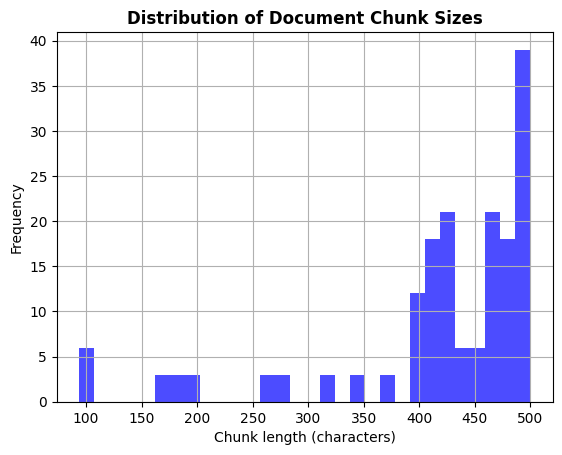

Average chunk length: 416 chars


In [ ]:
chunk_lengths = [len(chunk.page_content) for chunk in chunks]
plt.hist(chunk_lengths, bins=30, alpha=0.7, color='blue')
plt.xlabel('Chunk length (characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Document Chunk Sizes', fontweight='bold')
plt.grid(True)
plt.show()
print(f"Average chunk length: {np.mean(chunk_lengths):.0f} chars")

### Set Up Retrieval QA Chain (with Groq)

In [ ]:
# If Groq API key was provided, use LangChain's RetrievalQA
if GROQ_API_KEY:
    # Custom prompt to include citations
    prompt_template = """
    You are a helpful assistant that answers questions based only on the provided context.
    If the answer is not in the context, say "I don't have enough information to answer that."

    Context:
    {context}

    Question: {question}

    Provide a concise answer and mention which source document(s) you used.
    Answer:
    """
    PROMPT = PromptTemplate(template=prompt_template, input_variables=["context", "question"])

    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=vectorstore.as_retriever(search_kwargs={"k": 4}),
        chain_type_kwargs={"prompt": PROMPT},
        return_source_documents=True
    )
    print("QA chain ready with Groq LLM.")
else:
    print("No API key. We'll implement a manual retrieval + free local LLM.")

    # Load a free local pipeline (slow but works)
    from transformers import pipeline
    generator = pipeline("text2text-generation", model="google/flan-t5-large", device_map="auto")

    def answer_with_local_llm(query):
        retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
        docs = retriever.get_relevant_documents(query)
        context = "\n\n".join([doc.page_content for doc in docs])
        prompt = f"Answer the question based only on the context.\nContext: {context}\nQuestion: {query}\nAnswer:"
        response = generator(prompt, max_length=200, do_sample=False)
        answer = response[0]['generated_text']
        return answer, docs

    qa_chain = None  # We'll use the function instead

QA chain ready with Groq LLM.


### Interactive Question Answering

In [ ]:
def ask_question(question):
    """Ask a question and get answer with sources."""
    if GROQ_API_KEY:
        result = qa_chain.invoke({"query": question})
        answer = result["result"]
        sources = set([doc.metadata.get("source", "unknown") for doc in result["source_documents"]])
    else:
        answer, docs = answer_with_local_llm(question)
        sources = set([doc.metadata.get("source", "unknown") for doc in docs])

    print(f"\n Question: {question}")
    print(f" Answer: {answer}")
    print(f" Sources: {', '.join(sources)}")
    return answer, sources

# Test with a sample question (you can change this)
test_question = "What is the main topic of the first uploaded document?"
print("Testing the system with a sample question...")
ask_question(test_question)

Testing the system with a sample question...

 Question: What is the main topic of the first uploaded document?
 Answer: The main topic of the first uploaded document appears to be image preprocessing and data standardization for a sonar image dataset, specifically the UATD dataset.

I used the first three paragraphs of the uploaded documents as the source.
 Sources: Paper 3 ibrahim jcbi detection (2).pdf, Paper 3 ibrahim jcbi detection (1).pdf, Paper 3 ibrahim jcbi detection.pdf


('The main topic of the first uploaded document appears to be image preprocessing and data standardization for a sonar image dataset, specifically the UATD dataset.\n\nI used the first three paragraphs of the uploaded documents as the source.',
 {'Paper 3 ibrahim jcbi detection (1).pdf',
  'Paper 3 ibrahim jcbi detection (2).pdf',
  'Paper 3 ibrahim jcbi detection.pdf'})

### User Input Loop (Run this cell to chat)

In [ ]:
print("\n" + "="*50)
print("PDF Q&A System Ready. Type 'exit' to stop.")
print("="*50)

while True:
    query = input("\n Your question: ").strip()
    if query.lower() in ["exit", "quit"]:
        print("Exiting. Goodbye!")
        break
    if not query:
        continue
    ask_question(query)


PDF Q&A System Ready. Type 'exit' to stop.

 Your question: What is this pdf about?

 Question: What is this pdf about?
 Answer: This PDF appears to be a technical document describing the architecture and preprocessing of a deep learning model for sonar image classification, specifically the UATD dataset.

I used the provided context to answer this question.
 Sources: Paper 3 ibrahim jcbi detection (2).pdf, Paper 3 ibrahim jcbi detection (1).pdf, Paper 3 ibrahim jcbi detection.pdf

 Your question: What is the exact topic and author name?

 Question: What is the exact topic and author name?
 Answer: I don't have enough information to answer that.
 Sources: Paper 3 ibrahim jcbi detection (2).pdf, Paper 3 ibrahim jcbi detection (1).pdf, Paper 3 ibrahim jcbi detection.pdf

 Your question: exit
Exiting. Goodbye!


### Save FAISS Index for Future Use (Optional)

In [ ]:
# Save index to Google Drive
from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/rag_pdf_faiss_index'
vectorstore.save_local(save_path)
print(f"FAISS index saved to {save_path}")

# Later, you can load with:
# vectorstore = FAISS.load_local(save_path, embedding_model, allow_dangerous_deserialization=True)

Mounted at /content/drive
FAISS index saved to /content/drive/MyDrive/rag_pdf_faiss_index


### Performance Metrics & Final Summary

In [ ]:
# Measure retrieval + generation time
start = time.time()
ask_question("What is the most repeated key concept?")
end = time.time()
print(f"\n⏱ Round-trip time: {end-start:.2f} seconds")

print("\n" + "="*50)
print("RAG Project 1: The Core Memory Bank - COMPLETED")
print("Author: Ibrahim")
print("="*50)
print(f" Processed PDFs: {len(uploaded)}")
print(f" Total chunks: {len(chunks)}")
print(f" Vector store: FAISS with all-MiniLM-L6-v2")
print(f" LLM: {'Groq Llama3' if GROQ_API_KEY else 'flan-t5-large (local)'}")
print("\n You can now ask questions about your PDFs.")
print(" Sources are automatically cited.")
print(" The system is ready for deployment or further tuning.")


 Question: What is the most repeated key concept?
 Answer: The most repeated key concept is "recall" and its related properties, specifically in the context of safety-critical classes and precision-recall analysis.

I used the provided context (the three paragraphs) to determine this answer.
 Sources: Paper 3 ibrahim jcbi detection (2).pdf, Paper 3 ibrahim jcbi detection (1).pdf, Paper 3 ibrahim jcbi detection.pdf

⏱ Round-trip time: 0.39 seconds

RAG Project 1: The Core Memory Bank - COMPLETED
Author: Ibrahim
 Processed PDFs: 1
 Total chunks: 171
 Vector store: FAISS with all-MiniLM-L6-v2
 LLM: Groq Llama3

 You can now ask questions about your PDFs.
 Sources are automatically cited.
 The system is ready for deployment or further tuning.
